**Email Campaign by Raka arrayan**

# Metadata

Berikut adalah penjelasan masing-masing kolom dalam dataset:

- Email_ID: ID unik untuk setiap email.

- Email_Type: Kategori atau tipe email. Misalnya, tipe 1 mungkin merujuk pada email promosi, sementara tipe 2 mungkin merujuk pada email pemberitahuan.

- Subject_Hotness_Score: Skor yang menunjukkan seberapa menarik subjek email tersebut, yang mungkin didasarkan pada analisis teks atau respon pengguna sebelumnya.

- Email_Source_Type: Tipe sumber email, misalnya, dari internal perusahaan atau sumber eksternal.

- Customer_Location: Lokasi pelanggan yang menerima email, diwakili dengan huruf.

- Email_Campaign_Type: Tipe kampanye email yang dikirim

- Total_Past_Communications: Total komunikasi atau interaksi sebelumnya dengan pelanggan ini.

- Time_Email_sent_Category: Kategori waktu pengiriman email, yang mungkin dibagi dalam beberapa slot waktu

- Word_Count: Jumlah kata dalam email.

- Total_Links: Total jumlah tautan yang disertakan dalam email.

- Total_Images: Total jumlah gambar yang disertakan dalam email.

- Email_Status: Status email, misalnya, 0 untuk email yang tidak dibuka,  1 untuk email yang dibuka dan  2 untuk email yang dibalas.

# Background

Di era digital saat ini, pemilik usaha kecil dan menengah semakin banyak menggunakan strategi pemasaran berbasis email melalui Gmail untuk mengubah calon pelanggan menjadi pelanggan setia. Email pemasaran memungkinkan bisnis untuk mengkarakterisasi dan melacak interaksi, seperti apakah email diabaikan, dibaca, atau diakui oleh penerima, yang membantu mengukur efektivitas kampanye. Terinspirasi oleh prinsip bahwa pengeluaran iklan berbanding lurus dengan penjualan, analisis regresi dapat digunakan untuk mengukur hubungan ini secara tepat. Kami mendorong semua orang untuk bereksperimen dengan data ini dan mengeksplorasi nilai email sebagai alat dalam strategi pemasaran multisaluran untuk usaha kecil dan menengah.

# Goals

Dataset ini bertujuan untuk menganalisis dan meningkatkan efektivitas kampanye email dengan mempelajari berbagai faktor yang mempengaruhi apakah email dibuka atau tidak oleh pelanggan. Analisis mencakup elemen-elemen seperti tipe email, skor daya tarik subjek, sumber email, lokasi pelanggan, tipe kampanye, jumlah komunikasi sebelumnya, waktu pengiriman email, serta konten email yang meliputi jumlah kata, tautan, dan gambar. Dengan menganalisis data ini, perusahaan dapat memperoleh wawasan yang berguna untuk merancang kampanye email yang lebih menarik, mengoptimalkan waktu pengiriman, dan personalisasi email berdasarkan preferensi pelanggan, sehingga meningkatkan tingkat pembukaan dan engagement pelanggan

# Data Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
upload=files.upload()

Saving Email_Campaign.ipynb to Email_Campaign.ipynb


In [ ]:
df = pd.read_csv('Email_Campaign.csv')
df.head()

,Email_ID,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
0,EMA00081000034500,1,2.2,2,E,2,33.0,1,440,8.0,0.0,0
1,EMA00081000045360,2,2.1,1,NaN,2,15.0,2,504,5.0,0.0,0
2,EMA00081000066290,2,0.1,1,B,3,36.0,2,962,5.0,0.0,1
3,EMA00081000076560,1,3.0,2,E,2,25.0,2,610,16.0,0.0,0
4,EMA00081000109720,1,0.0,2,C,3,18.0,2,947,4.0,0.0,0


In [ ]:
df.shape

(68353, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68353 entries, 0 to 68352
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Email_ID                   68353 non-null  object 
 1   Email_Type                 68353 non-null  int64  
 2   Subject_Hotness_Score      68353 non-null  float64
 3   Email_Source_Type          68353 non-null  int64  
 4   Customer_Location          56758 non-null  object 
 5   Email_Campaign_Type        68353 non-null  int64  
 6   Total_Past_Communications  61528 non-null  float64
 7   Time_Email_sent_Category   68353 non-null  int64  
 8   Word_Count                 68353 non-null  int64  
 9   Total_Links                66152 non-null  float64
 10  Total_Images               66676 non-null  float64
 11  Email_Status               68353 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 6.3+ MB


### Duplicate

In [ ]:
df.duplicated().sum()

0

### Missing Value

In [ ]:
missing_data = df.isnull().sum()
#isnull() akan memeriksa setiap elemen dalam DataFrame df dan mengembalikan DataFrame baru dengan nilai boolean (True atau False)
print(missing_data)

Email_ID                         0
Email_Type                       0
Subject_Hotness_Score            0
Email_Source_Type                0
Customer_Location            11595
Email_Campaign_Type              0
Total_Past_Communications     6825
Time_Email_sent_Category         0
Word_Count                       0
Total_Links                   2201
Total_Images                  1677
Email_Status                     0
dtype: int64


1. Customer_Location (11,595 missing values)
- Pendekatan: Mengisi dengan nilai modus (lokasi yang paling sering muncul).
- Alasan: Mengisi nilai yang hilang dengan modus memastikan bahwa penggantian ini konsisten dengan data yang ada. Karena modus adalah nilai yang paling sering muncul, kemungkinan besar ini adalah nilai yang representatif untuk kolom tersebut.
2. Total_Past_Communications (6,825 missing values)
- Pendekatan: Mengisi dengan nilai median atau rata-rata.
- Alasan: Total komunikasi sebelumnya dapat memberikan konteks mengenai hubungan dengan pelanggan. Menggunakan median atau rata-rata dapat memberikan nilai yang wajar tanpa terlalu mengubah distribusi data.
3. Total_Links (2,201 missing values)
- Pendekatan: Mengisi dengan 0.
- Alasan: Jika jumlah tautan tidak ada dalam email, kemungkinan besar memang tidak ada tautan yang dimasukkan.
4. Total_Images (1,677 missing values)
- Pendekatan: Mengisi dengan 0.
- Alasan: Sama dengan jumlah tautan, jika tidak ada gambar dalam email, kemungkinan besar memang tidak ada gambar yang dimasukkan.

In [ ]:
# Mengisi missing values pada Customer_Location dengan modus
df['Customer_Location'].fillna(df['Customer_Location'].mode()[0], inplace=True)
# df['Customer_Location'] Mengakses kolom Customer_Location dari DataFrame df
# fillna() digunakan untuk mengganti nilai NaN atau nilai yang hilang dalam kolom dengan nilai pengganti yang ditentukan.
# .mode() mengembalikan modus dari kolom tersebut
# [0] digunakan untuk memilih nilai modus yang paling sering muncul
# inplace=True memastikan bahwa perubahan dilakukan langsung pada DataFrame df yang sudah ada, bukan membuat salinan DataFrame baru

# Mengisi missing values pada Total_Past_Communications dengan median
df['Total_Past_Communications'].fillna(df['Total_Past_Communications'].median(), inplace=True)
# .median() menghitung median dari kolom Total_Past_Communications

# Mengisi missing values pada Total_Links dengan 0
df['Total_Links'].fillna(0, inplace=True)

# Mengisi missing values pada Total_Images dengan 0
df['Total_Images'].fillna(0, inplace=True)


# Exploraty Data analysis

In [ ]:
df.describe()

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
count,68353.000000,68353.000000,68353.000000,68353.000000,68353.000000,68353.000000,68353.000000,68353.00000,68353.000000,68353.000000
mean,1.285094,1.095481,1.456513,2.272234,28.840066,1.999298,699.931751,10.09369,3.463564,0.230934
std,0.451462,0.997578,0.498109,0.468680,11.897462,0.631103,271.719440,6.54400,5.555121,0.497032
min,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,40.000000,0.00000,0.000000,0.000000
25%,1.000000,0.200000,1.000000,2.000000,20.000000,2.000000,521.000000,6.00000,0.000000,0.000000
50%,1.000000,0.800000,1.000000,2.000000,28.000000,2.000000,694.000000,9.00000,0.000000,0.000000
75%,2.000000,1.800000,2.000000,3.000000,37.000000,2.000000,880.000000,14.00000,5.000000,0.000000
max,2.000000,5.000000,2.000000,3.000000,67.000000,3.000000,1316.000000,49.00000,45.000000,2.000000


# Processing data

### Outliers

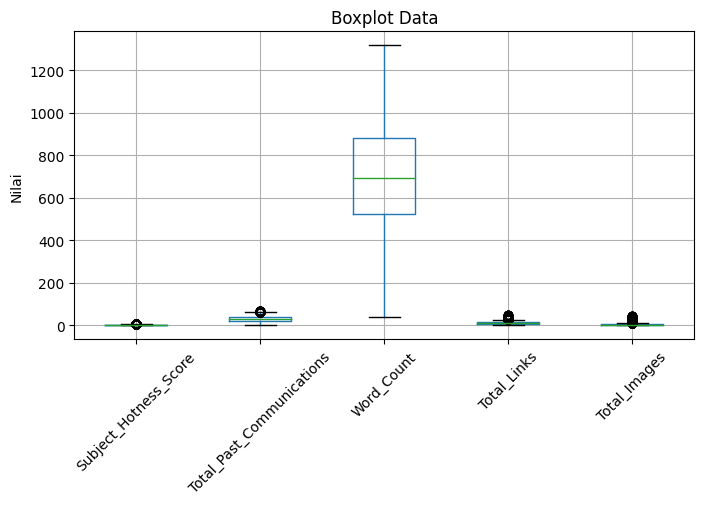

Data Outlier:
Subject_Hotness_Score         247
Total_Past_Communications     136
Word_Count                      0
Total_Links                  1608
Total_Images                 5585
dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')  # Mengabaikan peringatan

# Membuat objek DataFrame baru bernama dataset dari DataFrame yang sudah ada yaitu  df
dataset = pd.DataFrame(df)

# Mengatur ukuran figure (gambar) untuk plot dengan lebar 8 inci dan tinggi 4 inci.
plt.figure(figsize=(8, 4))

# Memilih kolom-kolom yang akan diplot boxplot
cols_to_plot = ['Subject_Hotness_Score', 'Total_Past_Communications', 'Word_Count', 'Total_Links', 'Total_Images']
dataset[cols_to_plot].boxplot() # Membuat boxplot untuk setiap kolom yang dipilih dalam cols_to_plot dari DataFrame dataset.

# Menambahkan judul dan label sumbu y
plt.title('Boxplot Data')#menambahkan judul "Boxplot Data" pada plot.
plt.ylabel('Nilai')#menambahkan label sumbu y dengan teks "Nilai".

# Mengatur label sumbu x agar rapi
plt.xticks(ticks=range(1, len(cols_to_plot) + 1), labels=cols_to_plot, rotation=45)
plt.show()# menampilkan plot yang telah dibuat.
# ticks=range(1, len(cols_to_plot) + 1) menentukan posisi ticks pada sumbu x sesuai dengan jumlah kolom yang akan diplot.
# labels=cols_to_plot menetapkan label ticks sesuai dengan nama kolom yang dipilih.
# rotation=45 memutar label ticks sebesar 45 derajat agar tidak saling bertumpukan dan lebih mudah dibaca

# Menghitung Q1, Q3, dan IQR untuk kolom numerik saja
Q1 = dataset[cols_to_plot].quantile(0.25)#menghitung kuartil pertama (Q1) untuk setiap kolom dalam daftar cols_to_plot. Q1 adalah nilai di bawah 25% data.
Q3 = dataset[cols_to_plot].quantile(0.75)# menghitung kuartil ketiga (Q3) untuk setiap kolom dalam daftar cols_to_plot. Q3 adalah nilai di bawah 75% data
IQR = Q3 - Q1# (Interquartile Range) adalah selisih antara Q3 dan Q1. IQR mengukur rentang di mana 50% data tengah terletak dan digunakan untuk mendeteksi outliers

# Mengidentifikasi outliers
outliers = ((dataset[cols_to_plot] < (Q1 - 1.5 * IQR)) | (dataset[cols_to_plot] > (Q3 + 1.5 * IQR))).sum()
# dataset[cols_to_plot] < (Q1 - 1.5 * IQR) membuat DataFrame boolean yang menunjukkan nilai-nilai yang lebih kecil dari batas bawah untuk outliers.
# dataset[cols_to_plot] > (Q3 + 1.5 * IQR) membuat DataFrame boolean yang menunjukkan nilai-nilai yang lebih besar dari batas atas untuk outliers.
# .sum() menghitung jumlah nilai True (outliers) dalam setiap kolom, memberikan jumlah total outliers per kolom.

# Menampilkan jumlah outliers per kolom
print('Data Outlier:')
print(outliers)


1. Subject_Hotness_Score (247 outliers)
- Pendekatan: Pertimbangkan untuk mengganti outliers dengan nilai Q1 atau Q3. Hal ini dapat dilakukan jika outliers tidak signifikan secara bisnis atau analisis.

2. Total_Past_Communications (136 outliers)

- Pendekatan: Mengganti outliers dengan median atau batas kuartil  lebih cocok untuk menjaga informasi komunikasi sebelumnya.

3. Word_Count (0 outliers)
- Tidak ada tindakan yang diperlukan karena tidak ada outliers.

4. Total_Links (1608 outliers)

- Pendekatan: Mengganti outliers dengan nilai Q1 atau Q3.

5. Total_Images (5585 outliers)

- Pendekatan: Mengganti outliers dengan nilai Q1 atau Q3

Deskripsi Data Setelah Menangani Outliers:
       Subject_Hotness_Score  Total_Past_Communications    Word_Count  \
count           68353.000000               68353.000000  68353.000000   
mean                1.085633                  28.785525    699.931751   
std                 0.976829                  11.796545    271.719440   
min                 0.000000                   0.000000     40.000000   
25%                 0.200000                  20.000000    521.000000   
50%                 0.800000                  28.000000    694.000000   
75%                 1.800000                  37.000000    880.000000   
max                 4.200000                  62.000000   1316.000000   

        Total_Links  Total_Images  
count  68353.000000  68353.000000  
mean       9.667696      2.398300  
std        5.590513      3.236682  
min        0.000000      0.000000  
25%        6.000000      0.000000  
50%        9.000000      0.000000  
75%       14.000000      5.000000  
max       2

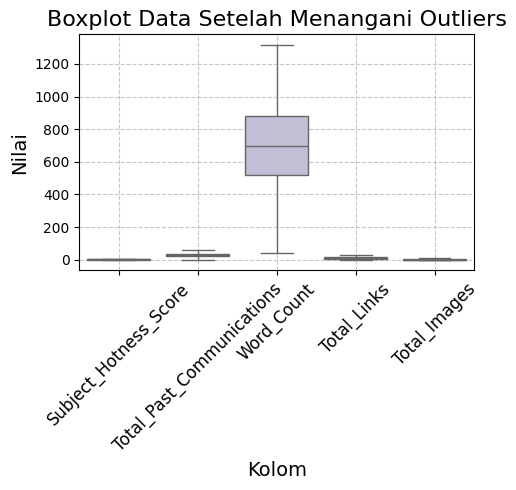

In [ ]:
import warnings

warnings.filterwarnings('ignore')  # Mengabaikan peringatan

# Membuat DataFrame dari dataset
dataset = pd.DataFrame(df)

# Memilih kolom-kolom yang akan diplot boxplot
cols_to_plot = ['Subject_Hotness_Score', 'Total_Past_Communications', 'Word_Count', 'Total_Links', 'Total_Images']

# Mengganti outliers dengan nilai Q1 dan Q3
for col in cols_to_plot:# digunakan untuk iterasi melalui setiap kolom yang ada dalam daftar cols_to_plot
    Q1 = dataset[col].quantile(0.25)# menghitung kuartil pertama (Q1)
    Q3 = dataset[col].quantile(0.75)# menghitung kuartil ketiga (Q3)
    IQR = Q3 - Q1# menghitung rentang interkuartil (IQR) sebagai selisih antara Q3 dan Q1.
    lower_bound = Q1 - 1.5 * IQR # menghitung batas bawah untuk mendeteksi outliers
    upper_bound = Q3 + 1.5 * IQR # menghitung batas atas untuk mendeteksi outliers.

    # Mengganti nilai di bawah lower_bound dengan Q1 dan di atas upper_bound dengan Q3
    dataset.loc[dataset[col] < lower_bound, col] = Q1 #  menggantikan nilai-nilai yang lebih kecil dari batas bawah dengan nilai Q1.
    dataset.loc[dataset[col] > upper_bound, col] = Q3 # menggantikan nilai-nilai yang lebih besar dari batas atas dengan nilai Q3.

# Verifikasi apakah outliers telah ditangani
print('Deskripsi Data Setelah Menangani Outliers:')
print(dataset[cols_to_plot].describe())

# Membuat figure atau kanvas baru dengan ukuran 12x8 inci
plt.figure(figsize=(5,5))

# Menggunakan seaborn untuk membuat boxplot yang lebih menarik
sns.boxplot(data=dataset[cols_to_plot], palette="Set3")

# Menambahkan judul dan label sumbu y
plt.title('Boxplot Data Setelah Menangani Outliers', fontsize=16)
plt.ylabel('Nilai', fontsize=14)
plt.xlabel('Kolom', fontsize=14)

# Mengatur label sumbu x agar rapi dan lebih besar
plt.xticks(ticks=range(len(cols_to_plot)), labels=cols_to_plot, rotation=45, fontsize=12)

# Menambahkan grid untuk memperjelas
plt.grid(True, linestyle='--', alpha=0.7)

# Menampilkan plot
plt.tight_layout()  # Untuk memastikan elemen plot tidak tumpang tindih
plt.show()


# ==============================================ILUSTRASI SEDERHANA==============================================
# Misalkan kita memiliki dataset dengan satu kolom Score
# 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 1000
# Posisi Q1 = 0.25 * (n + 1),n adalah jumlah data.
# Posisi Q1 = 0.25 * (11 + 1) = 0.25 * 12 = 3 ---> sehinga Q1 = 55
# Posisi Q3 = 0.75 * (n + 1),n adalah jumlah data.
# Posisi Q3 = 0.75 * (11 + 1) = 0.75 * 12 = 9 ---> sehingga Q3= 85
# IQR = Q3 - Q1 =85 - 55 = 30
# Batas Bawah = Q1 - 1.5 * IQR =55 - 1.5 * 30 = 55 - 45 = 10
# Batas Atas = Q3 + 1.5 * IQR = 85 + 1.5 * 30 = 85 + 45 = 130
# Nilai yang lebih kecil dari 10 atau lebih besar dari 130 dianggap sebagai outliers.
# Dalam dataset, nilai 1000 adalah outlier karena lebih besar dari 130
# Nilai 1000 diganti dengan Q3 (85).
# Menjadi 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 85
# ===============================================================================================================





Apakah ada distribusi yang tidak masuk akal?

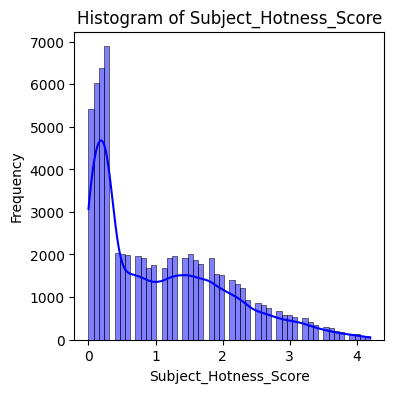

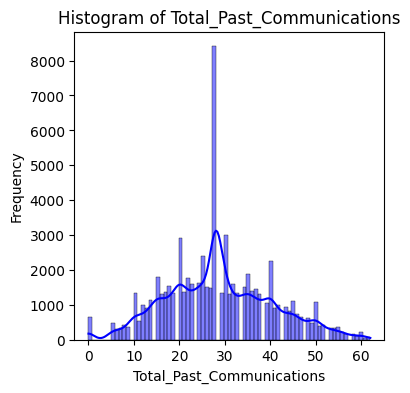

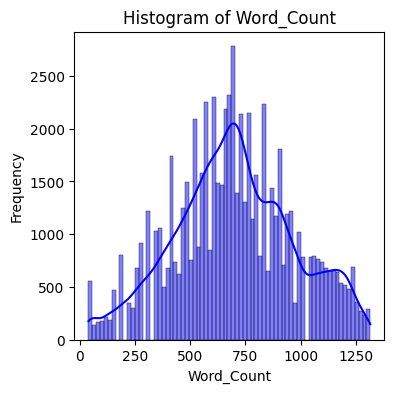

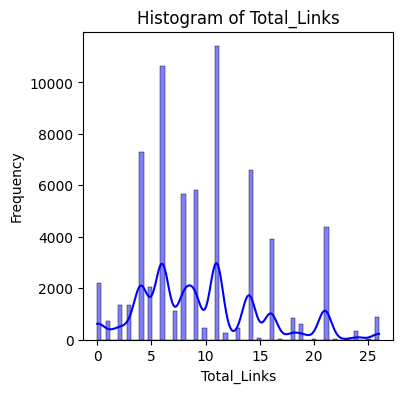

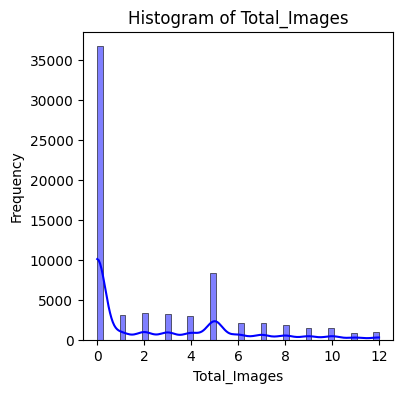

In [ ]:
# Mengabaikan peringatan
warnings.filterwarnings('ignore')

# Membuat DataFrame dari dataset
dataset = pd.DataFrame(df)

# Memilih kolom-kolom yang akan dianalisis
cols_to_check = ['Subject_Hotness_Score', 'Total_Past_Communications', 'Word_Count', 'Total_Links', 'Total_Images']

# Fungsi untuk memplot hanya histogram
def plot_histogram(col):# Mendefinisikan sebuah fungsi bernama plot_histogram yang menerima parameter col.
    plt.figure(figsize=(4, 4))
    sns.histplot(dataset[col], kde=True, color='blue')
    # dataset[col]: Menentukan data yang akan digunakan untuk histogram, yaitu data dari kolom yang diberikan.
    # kde=True: Menambahkan garis kurva  (Kernel Density Estimate) pada histogram
    # color='blue': Menentukan warna histogram dan kurva KDE menjadi biru.
    plt.title(f'Histogram of {col}')
    # color='blue': Menentukan warna histogram dan kurva KDE menjadi biru.
    # menggunakan format string f-string untuk memasukkan nama kolom ke dalam judul.
    plt.xlabel(col)# Menambahkan label pada sumbu x, yang sesuai dengan nama kolom.
    plt.ylabel('Frequency')# Menambahkan label pada sumbu y
    plt.show()# Menampilkan histogram yang telah dibuat

# Memeriksa distribusi untuk setiap kolom yang dipilih
for col in cols_to_check:#  perulangan (loop) yang akan mengambil setiap elemen  dari daftar cols_to_check.
    plot_histogram(col)
    # Di dalam loop, plot_histogram(col) dipanggil untuk setiap elemen yang diambil dari cols_to_check.
    # col adalah variabel yang menyimpan nama kolom saat ini dari list cols_to_check


Kesimpulan :           

- Sebagian besar distribusi ini menunjukkan data yang miring ke kanan, terutama pada Subject_Hotness_Score, Total_Past_Communications, Total_Links, dan Total_Images, yang menunjukkan bahwa kebanyakan nilai berkumpul di nilai rendah.
- Distribusi Word_Count tampaknya mengikuti distribusi normal yang lebih seimbang.
- Tidak ada distribusi yang terlihat sangat tidak wajar, tetapi beberapa distribusi menunjukkan adanya data yang sangat berpusat pada nilai rendah, yang bisa jadi merupakan karakteristik alami dari data

# Data Insight

## Email Type

<Axes: xlabel='Email_Type', ylabel='Count'>

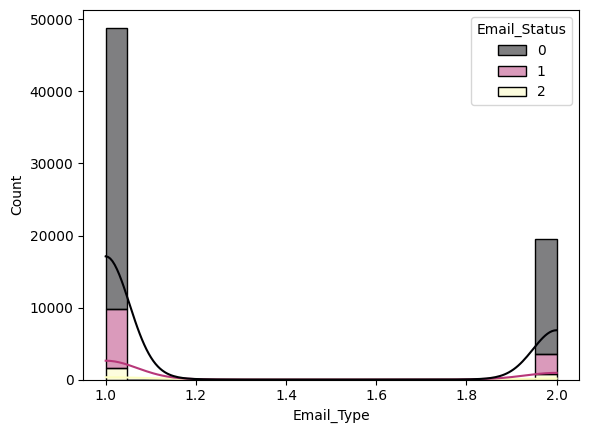

In [ ]:
sns.histplot(data=df, x='Email_Type', hue='Email_Status', multiple='stack', kde=True, palette='magma')

**Kesimpulan dari grafik:**
- Email Status 0 (Tidak Dibuka):

Sebagian besar email dengan tipe 1 dan 2 tidak dibuka,
Ini menunjukkan bahwa banyak email tidak dibuka

- Email Status 1 (Dibuka):

Email dengan status 1 (dibuka) terlihat dalam jumlah yang jauh lebih kecil dibandingkan dengan status 0.

- Email Status 2 (Dibalas):

Email yang dibalas (status 2) memiliki jumlah yang paling sedikit di antara ketiga status.


**Insight**:
- Efektivitas Tipe Email:

Kedua tipe email (1dan 2) tampaknya tidak efektif dalam menarik perhatian penerima, karena sebagian besar dari mereka tidak membuka email tersebut.

- Strategi Kampanye Email:

Perusahaan mungkin perlu mengevaluasi ulang konten dan strategi pengiriman untuk kedua tipe email ini untuk meningkatkan tingkat keterbukaan dan tanggapan.

## Subject Hotness Score

<Axes: xlabel='Subject_Hotness_Score', ylabel='Count'>

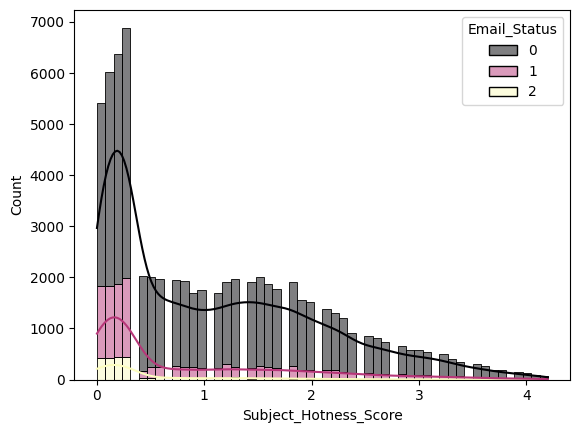

In [ ]:
sns.histplot(data=df, x='Subject_Hotness_Score', hue='Email_Status', multiple='stack', kde=True,palette='magma')

Kesimpulan :               
- Dari grafik di atas, dapat disimpulkan bahwa sebagian besar email memiliki Subject_Hotness_Score rendah (0 hingga 1), dan mayoritas dari mereka tidak dibuka, seperti yang ditunjukkan oleh tingginya jumlah email dengan status 0 (tidak dibuka) pada skor tersebut. Jumlah email yang dibuka (status 1) dan dibalas (status 2) jauh lebih sedikit, dengan frekuensi yang menurun seiring dengan peningkatan Subject_Hotness_Score.

- Efektivitas Skor Subjek: Subject_Hotness_Score yang lebih tinggi tidak menjamin email akan dibuka atau dibalas. Bahkan, sebagian besar email dengan skor rendah tetap tidak dibuka.
- Perlu Perbaikan Konten:Strategi peningkatan kualitas subjek email perlu diperhatikan, karena Subject_Hotness_Score yang rendah dominan di sebagian besar email.

## Email Source Type

<Axes: xlabel='Email_Source_Type', ylabel='Count'>

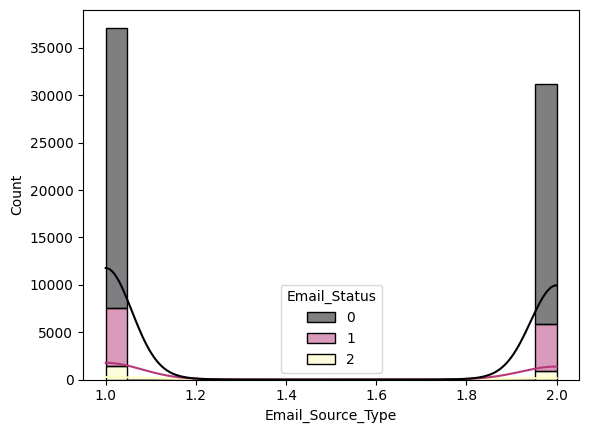

In [ ]:
sns.histplot(data=df, x='Email_Source_Type', hue='Email_Status', multiple='stack', kde=True,palette='magma')

Kesimpulan:

- Efektivitas Sumber Email:
Kedua sumber email (1 dan 2) tampaknya tidak efektif dalam menarik perhatian penerima, karena sebagian besar dari mereka tidak membuka email tersebut.

- Strategi Kampanye Email: Perusahaan mungkin perlu mengevaluasi ulang strategi pengiriman dari kedua sumber ini untuk meningkatkan tingkat keterbukaan dan tanggapan.

## Customer Location

<Axes: xlabel='Customer_Location', ylabel='Count'>

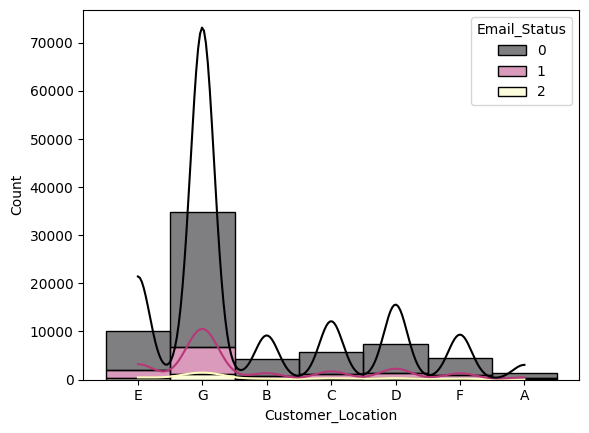

In [ ]:
sns.histplot(data=df, x='Customer_Location', hue='Email_Status', multiple='stack', kde=True,palette='magma')

Kesimpulan:
- Insight dari grafik ini menunjukkan bahwa lokasi G memiliki jumlah pelanggan yang sangat dominan, menunjukkan potensi pasar yang lebih besar di lokasi ini dibandingkan dengan lokasi lainnya. Sebagian besar pelanggan memiliki status email 0, yang bisa berarti mereka adalah pelanggan yang tidak aktif atau belum merespons email. Lokasi lain memiliki jumlah pelanggan yang lebih rendah, tetapi lokasi E dan D menunjukkan sedikit potensi dibandingkan lokasi B, C, F, dan A. Ini menunjukkan bahwa strategi pemasaran atau komunikasi yang lebih intensif dan terfokus mungkin diperlukan di lokasi-lokasi ini untuk meningkatkan keterlibatan pelanggan. Selain itu, upaya untuk meningkatkan keterlibatan pelanggan dengan status email 1 dan 2 juga diperlukan untuk memastikan mereka tetap terhubung dan aktif.

## Email Campaign Type

<Axes: xlabel='Email_Campaign_Type', ylabel='Count'>

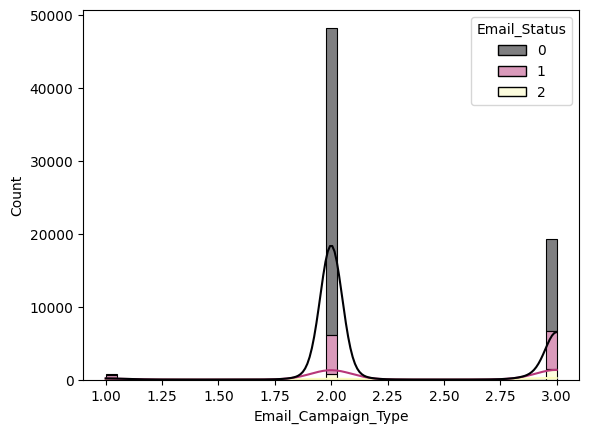

In [ ]:
sns.histplot(data=df, x='Email_Campaign_Type', hue='Email_Status', multiple='stack', kde=True,palette='magma')

Kesimpulan :         
- Grafik menunjukkan bahwa tipe kampanye email 2 memiliki jumlah pelanggan tertinggi, dengan mayoritas memiliki status email 0, yang menunjukkan bahwa mereka tidak aktif atau tidak terlibat. Tipe kampanye 3 memiliki jumlah pelanggan yang cukup signifikan namun lebih rendah dibandingkan tipe 2, sementara tipe kampanye 1 hampir tidak memiliki pelanggan yang terlibat, menandakan efektivitas yang rendah atau kurangnya penggunaan tipe kampanye ini.

- Dapat disimpulkan bahwa kampanye email tipe 2 perlu dievaluasi dan ditingkatkan untuk mengubah status email 0 menjadi status yang lebih aktif. Tipe kampanye 1 memerlukan revisi atau strategi baru untuk meningkatkan keterlibatan pelanggan. Optimalisasi kampanye tipe 3 juga penting untuk meningkatkan efektivitasnya berdasarkan respon pelanggan yang sudah ada.

## Total Past Communications

<Axes: xlabel='Total_Past_Communications', ylabel='Count'>

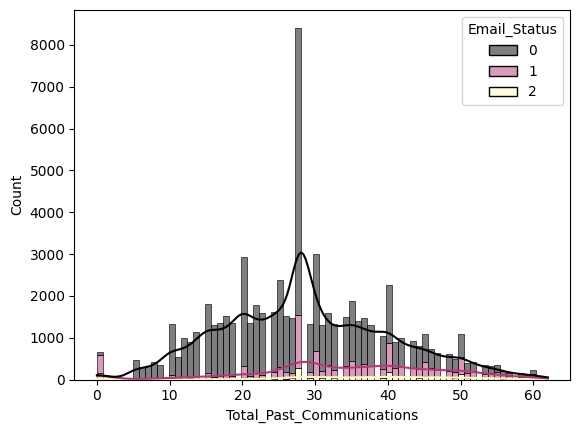

In [ ]:
sns.histplot(data=df, x='Total_Past_Communications', hue='Email_Status', multiple='stack', kde=True,palette='magma')

Kesimpulan :        
- Grafik  memperlihatkan bahwa pelanggan yang telah berkomunikasi sekitar 30 kali menunjukkan puncak tertinggi dalam distribusi jumlah komunikasi, dengan mayoritas dari mereka memiliki status email 0. Distribusi ini juga menunjukkan bahwa ada pelanggan yang telah berkomunikasi dalam berbagai jumlah hingga lebih dari 50 kali, menandakan variasi dalam keterlibatan pelanggan.

- Insight dari grafik kedua menunjukkan bahwa upaya perlu difokuskan pada pelanggan yang telah berkomunikasi sekitar 30 kali untuk meningkatkan keterlibatan dan mengubah status email mereka dari 0 menjadi lebih aktif. Pelanggan dengan jumlah komunikasi rendah memerlukan pendekatan yang lebih personal, sementara strategi reaktivasi diperlukan untuk pelanggan dengan jumlah komunikasi sangat tinggi agar mereka tetap terlibat.

## Time Email sent Category

<Axes: xlabel='Time_Email_sent_Category', ylabel='Count'>

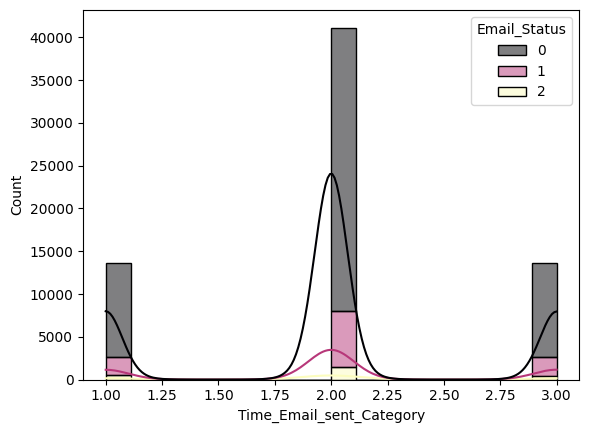

In [ ]:
 sns.histplot(data=df, x='Time_Email_sent_Category', hue='Email_Status', multiple='stack', kde=True,palette='magma')

Kesimpulan:
-  Dari grafik ini, kita dapat menyimpulkan bahwa kategori waktu 2 memiliki jumlah email yang dikirim paling banyak, dengan mayoritas status email 0 (ditandai dengan warna abu-abu). Kategori waktu 1 dan 3 memiliki jumlah email yang dikirim lebih sedikit dibandingkan dengan kategori 2. Status email 0 mendominasi pada semua kategori waktu, sedangkan status 1 dan 2 hanya memiliki jumlah yang kecil pada semua kategori waktu.

- Kategori waktu 2 memiliki jumlah email yang dikirim paling banyak, perusahaan harus mempertimbangkan untuk mengirim lebih banyak email pada waktu ini.Walaupun kategori waktu 2 dominan, perusahaan juga harus mempertimbangkan untuk menguji efektivitas kategori waktu 1 dan 3 untuk melihat apakah ada peluang untuk meningkatkan keterlibatan pelanggan di waktu-waktu tersebut

## Word Count

<Axes: xlabel='Word_Count', ylabel='Count'>

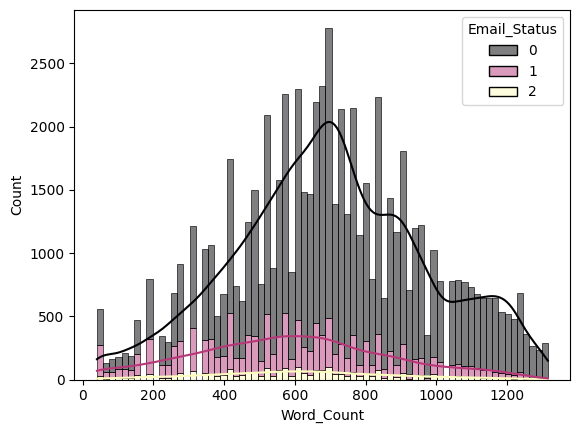

In [ ]:
 sns.histplot(data=df, x='Word_Count', hue='Email_Status', multiple='stack', kde=True,palette='magma')

Kesimpulan :             
-  Dari grafik ini, kita dapat menyimpulkan bahwa mayoritas email memiliki jumlah kata di sekitar 500-800 kata dengan status email 0. Distribusi jumlah kata tampak seperti distribusi normal dengan puncak sekitar 500-600 kata. Status email 0 (warna abu-abu) mendominasi pada semua rentang jumlah kata, sedangkan email dengan status 1 (warna merah muda) dan 2 (warna kuning) memiliki jumlah yang lebih kecil dibandingkan dengan status 0 pada semua rentang jumlah kata.

- Dengan mayoritas email yang dikirim memiliki jumlah kata di sekitar 500-800 kata dan status email 0 (unopened) mendominasi, perusahaan harus mempertimbangkan untuk mengevaluasi konten email yang dikirim. Mungkin perlu untuk menyederhanakan pesan, meningkatkan relevansi, atau membuat subjek email lebih menarik

## Total Links

<Axes: xlabel='Total_Links', ylabel='Count'>

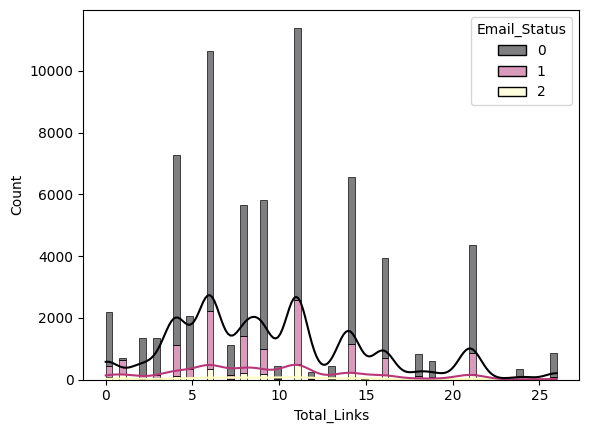

In [ ]:
 sns.histplot(data=df, x='Total_Links', hue='Email_Status', multiple='stack', kde=True,palette='magma')

Kesimpulan :

Dari grafik ini, kita dapat menyimpulkan bahwa mayoritas email memiliki Total link  di sekitar 5-10 link dengan status email 0. Distribusi jumlah kata tampak seperti distribusi normal dengan puncak sekitar 10 link. Status email 0 (warna abu-abu) mendominasi pada semua rentang jumlah kata, sedangkan email dengan status 1 (warna merah muda) dan 2 (warna kuning) memiliki jumlah yang lebih kecil dibandingkan dengan status 0 pada semua rentang jumlah link.

Dengan mayoritas email yang dikirim mendapat status email 0 (tidak dibuka) mendominasi, perusahaan harus mempertimbangkan untuk mengurangi jumlah link dalam email. Terlalu banyak link dapat membuat email terlihat seperti spam,mungkin juga perusahaan jangan memberikan link berjumlah diatas 15 karena kita melihat bahwa total  link diatas 15 mengalami penurunan secara terus menerus .perusahaan juga dapat secara bertahap menambah link sesuai kebutuhan.

## Total Images

<Axes: xlabel='Total_Images', ylabel='Count'>

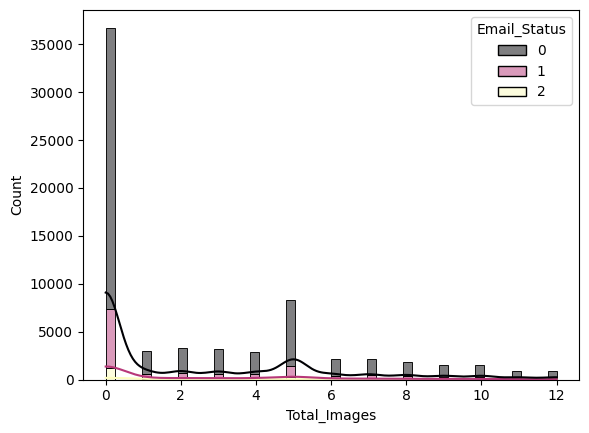

In [ ]:
 sns.histplot(data=df, x='Total_Images', hue='Email_Status', multiple='stack', kde=True,palette='magma')

Kesimpulan :

- Dari grafik ini, kita dapat menyimpulkan bahwa mayoritas email memiliki Total gambar 0 dengan status email 0.  Status email 0 (warna abu-abu) mendominasi pada semua rentang jumlah gambar, sedangkan email dengan status 1 (warna merah muda) dan 2 (warna kuning) memiliki jumlah yang lebih kecil.

- perusahaan harus mengevaluasi konten gambar yang disertakan. Gambar harus mendukung pesan utama dari email dan memberikan nilai tambahan bagi penerima, seperti menampilkan produk unggulan, promosi khusus, atau ilustrasi menarik yang mendukung konten teks.Dan juga perusahaan mungkin tidak perlu menggunakan gambar karena kita melihat bahwa Total images 0 mendapat cukup banyak status email 1

# Korelasi


In [ ]:
df[['Email_Type', 'Email_Status']].corr()[['Email_Status']]

,Email_Status
Email_Type,-0.015074
Email_Status,1.000000


In [ ]:
df[['Subject_Hotness_Score', 'Email_Status']].corr()[['Email_Status']]

,Email_Status
Subject_Hotness_Score,-0.151514
Email_Status,1.000000


In [ ]:
df[['Email_Source_Type', 'Email_Status']].corr()[['Email_Status']]

,Email_Status
Email_Source_Type,-0.024527
Email_Status,1.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Mengubah kolom 'Customer_Location' menjadi numerik
label_encoder = LabelEncoder()
df['Customer_Location_Encoded'] = label_encoder.fit_transform(df['Customer_Location'])

# Menampilkan korelasi termasuk kolom yang sudah diubah
df[['Customer_Location_Encoded', 'Email_Status']].corr()[['Email_Status']]


,Email_Status
Customer_Location_Encoded,0.001459
Email_Status,1.000000


In [ ]:
df[['Email_Campaign_Type', 'Email_Status']].corr()[['Email_Status']]

,Email_Status
Email_Campaign_Type,0.18551
Email_Status,1.00000


In [ ]:
df[['Total_Past_Communications', 'Email_Status']].corr()[['Email_Status']]

,Email_Status
Total_Past_Communications,0.231601
Email_Status,1.000000


In [ ]:
df[['Time_Email_sent_Category', 'Email_Status']].corr()[['Email_Status']]

,Email_Status
Time_Email_sent_Category,0.000051
Email_Status,1.000000


In [ ]:
df[['Word_Count', 'Email_Status']].corr()[['Email_Status']]

,Email_Status
Word_Count,-0.171116
Email_Status,1.000000


In [ ]:
df[['Total_Links', 'Email_Status']].corr()[['Email_Status']]

,Email_Status
Total_Links,-0.023717
Email_Status,1.000000


In [ ]:
df[['Total_Images', 'Email_Status']].corr()[['Email_Status']]

,Email_Status
Total_Images,-0.004439
Email_Status,1.000000


Kesimpulan :
- Variabel yang Memiliki Korelasi Positif dengan Email_Status:

Total_Past_Communications memiliki korelasi positif tertinggi dengan Email_Status (0.231601). Ini menunjukkan bahwa semakin banyak komunikasi sebelumnya, semakin besar kemungkinan status email tersebut aktif.
Email_Campaign_Type juga memiliki korelasi positif dengan Email_Status (0.18551). Ini menunjukkan bahwa tipe kampanye email dapat mempengaruhi status email.

- Variabel yang Memiliki Korelasi Negatif dengan Email_Status:

Subject_Hotness_Score memiliki korelasi negatif dengan Email_Status (-0.151514). Ini menunjukkan bahwa skor ketertarikan subjek yang lebih tinggi mungkin berkorelasi dengan status email yang tidak aktif.
Word_Count memiliki korelasi negatif (-0.171116). Ini menunjukkan bahwa email dengan jumlah kata lebih banyak mungkin cenderung memiliki status tidak aktif.

- Variabel yang Hampir Tidak Memiliki Korelasi dengan Email_Status:

Customer_Location_Encoded (0.001459), Time_Email_sent_Category (0.000051), Email_Source_Type (-0.024527), Total_Links (-0.023717), dan Total_Images (-0.004439) memiliki korelasi yang sangat rendah dengan Email_Status. Ini menunjukkan bahwa variabel-variabel ini tidak banyak berpengaruh pada status email.

- Tindakan untuk Variabel dengan Korelasi Rendah:

Customer_Location_Encoded (0.001459), Time_Email_sent_Category (0.000051), Email_Source_Type (-0.024527), Total_Links (-0.023717), Total_Images (-0.004439):
Korelasi rendah menunjukkan bahwa variabel-variabel ini tidak memiliki pengaruh signifikan terhadap Email_Status.

Tindakan: Meskipun variabel-variabel ini memiliki korelasi rendah, tetap penting untuk memantau mereka untuk kemungkinan adanya perubahan di masa depan. Namun, fokus utama sebaiknya pada variabel dengan korelasi yang lebih signifikan

- Rekomendasi tambahan

Segementasi Pelanggan:
Segmentasikan pelanggan berdasarkan riwayat komunikasi dan tipe kampanye yang mereka respon. Personalize komunikasi berdasarkan segmen-segmen ini untuk meningkatkan keterlibatan.

Uji A/B Testing:
Lakukan A/B testing untuk subjek email dan panjang konten. Temukan kombinasi yang paling efektif dalam menjaga status email aktif.


# Modeling Data

## Modeling Menggunakan Logistic Regression

Logistic regression dikenal juga sebagai logit regression, maximum- entropy classification, dan log-linear classification merupakan salah

satu metode yang umum digunakan untuk klasifikasi. Pada kasus klasifikasi, logistic regression bekerja dengan menghitung probabilitas kelas dari sebuah sampel.

Sesuai namanya, logistic regression menggunakan fungsi logistik seperti di bawah untuk menghitung probabilitas kelas dari sebuah sampel. Contohnya sebuah email memiliki probabilitas 78% merupakan spam maka email tersebut termasuk dalam kelas spam. Dan jika sebuah email memiliki < 50% probabilitas merupakan spam, maka email tersebut diklasifikasikan bukan spam.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Mempersiapkan Fitur dan Target
features = [
    'Subject_Hotness_Score',
    'Email_Source_Type',
    'Email_Campaign_Type',
    'Customer_Location',
    'Total_Past_Communications',
    'Word_Count',
    'Total_Links',
    'Total_Images'
]
X = df[features]
y = df['Email_Status']

# Fitur Kategorikal dan Numerik
categorical_features = [
    'Email_Source_Type',
    'Email_Campaign_Type',
    'Customer_Location'
]
numeric_features = [
    'Subject_Hotness_Score',
    'Total_Past_Communications',
    'Word_Count',
    'Total_Links',
    'Total_Images'
]

# Menggunakan OneHotEncoder untuk fitur kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Membangun Pipeline dengan Preprocessing dan Logistic Regression
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Membagi Data menjadi training dan test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Melatih Model
pipeline.fit(X_train, y_train)

# Prediksi dan Evaluasi
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print('Accuracy:', accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.98      0.90     16505
           1       0.48      0.14      0.22      3312
           2       0.00      0.00      0.00       689

    accuracy                           0.81     20506
   macro avg       0.43      0.37      0.37     20506
weighted avg       0.74      0.81      0.76     20506

Accuracy: 0.8094216326928704


## Modeling Menggunakan Random forest



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Mempersiapkan Fitur dan Target
features = [
    'Subject_Hotness_Score',
    'Email_Source_Type',
    'Email_Campaign_Type',
    'Customer_Location',
    'Total_Past_Communications',
    'Word_Count',
    'Total_Links',
    'Total_Images'
]
X = df[features]
y = df['Email_Status']

# Fitur Kategorikal dan Numerik
categorical_features = [
    'Email_Source_Type',
    'Email_Campaign_Type',
    'Customer_Location'
]
numeric_features = [
    'Subject_Hotness_Score',
    'Total_Past_Communications',
    'Word_Count',
    'Total_Links',
    'Total_Images'
]

# Menggunakan OneHotEncoder untuk fitur kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Membangun Pipeline dengan Preprocessing dan RandomForestClassifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Membagi Data menjadi training dan test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Melatih Model
pipeline.fit(X_train, y_train)

# Prediksi dan Evaluasi
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print('Accuracy:', accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.96      0.89     16505
           1       0.42      0.17      0.24      3312
           2       0.17      0.03      0.06       689

    accuracy                           0.80     20506
   macro avg       0.47      0.39      0.40     20506
weighted avg       0.74      0.80      0.76     20506

Accuracy: 0.8010338437530479


# Kesimpulan dan Rekomendasi

Kesimpulan :          

Analisis menunjukkan bahwa tingkat keterlibatan email rendah, dengan sebagian besar email tidak dibuka, terutama untuk tipe 1 dan 2. Meskipun Subject_Hotness_Score yang tinggi mungkin tampak menjanjikan, skor tersebut tidak selalu berkorelasi dengan tingkat keterbukaan atau balasan yang lebih tinggi. Tipe kampanye 2 memiliki potensi tetapi banyak email yang tetap tidak dibuka, sementara tipe kampanye 1 menunjukkan efektivitas yang rendah. Waktu pengiriman pada kategori 2 menunjukkan hasil yang terbaik, namun masih perlu evaluasi lebih lanjut. Konten email, seperti jumlah kata dan link, juga mempengaruhi keterbukaan, dengan terlalu banyak kata atau link berpotensi mengurangi efektivitas. Variabel seperti Total_Past_Communications menunjukkan korelasi positif dengan status email aktif, sementara Subject_Hotness_Score dan Word_Count menunjukkan korelasi negatif.

Rekomendasi:

Untuk meningkatkan efektivitas kampanye email, perusahaan harus memfokuskan perbaikan pada konten email dengan membuat subjek yang lebih menarik dan relevan serta menyederhanakan pesan. Jumlah kata, link, dan gambar dalam email juga perlu diperhatikan, dengan mengurangi elemen yang tidak mendukung pesan utama. Strategi pengiriman email harus dievaluasi lebih lanjut, termasuk uji waktu pengiriman untuk menemukan waktu yang optimal dan menyesuaikan frekuensi pengiriman agar tidak membebani penerima. Tipe kampanye yang kurang efektif harus diperbaiki, sementara tipe kampanye yang menunjukkan potensi perlu dioptimalkan. Fokus pada segmentasi pelanggan dan pendekatan personal dapat meningkatkan keterlibatan, serta pengembangan program reaktivasi untuk pelanggan yang tidak aktif. Terakhir, pemantauan kinerja secara berkelanjutan dan penerapan pendekatan berbasis data akan membantu dalam penyesuaian strategi dan peningkatan hasil kampanye email.